# 06 — Delivery Performance Analytics

## Olist E-Commerce Business Analytics

### Objective

This notebook evaluates Olist’s historical delivery performance and identifies operational patterns associated with customer satisfaction.

The analysis covers:

- Valid delivery population
- Delivery duration and on-time performance
- Delay severity
- Monthly operational trends
- Estimated versus actual delivery
- Review outcomes by delivery status
- Product-category delivery differences
- Operational investigation priorities

The analysis measures historical associations. It does not prove that delivery performance caused every review outcome or quantify guaranteed financial impact.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

PROCESSED_DATA_DIR = Path("../data/processed").resolve()
IMAGE_OUTPUT_DIR = Path(
    "../images/notebook_outputs"
).resolve()

IMAGE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed data:", PROCESSED_DATA_DIR.exists())
print("Image output:", IMAGE_OUTPUT_DIR.exists())

Processed data: True
Image output: True


In [2]:
order_analytics = pd.read_csv(
    PROCESSED_DATA_DIR / "order_analytics.csv",
    dtype={
        "customer_zip_code_prefix": "string"
    },
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "maximum_shipping_limit",
        "latest_review_date",
        "latest_review_answer_timestamp"
    ]
)

valid_deliveries = order_analytics.loc[
    order_analytics["is_valid_for_delivery_analysis"]
].copy()

print("All orders:", f"{len(order_analytics):,}")
print("Valid deliveries:", f"{len(valid_deliveries):,}")
print(
    "Valid-delivery coverage:",
    f"{len(valid_deliveries) / len(order_analytics):.2%}"
)

All orders: 99,441
Valid deliveries: 96,281
Valid-delivery coverage: 96.82%


***Population definition:*** Delivery analysis is limited to delivered orders with complete and chronologically valid purchase, carrier, customer-delivery, and estimated-delivery timestamps. Orders outside this population remain preserved but are not assigned delivery-performance outcomes.

## 1. Delivery Performance Baseline

The baseline summarises how long valid deliveries took, how frequently deadlines were met, and the typical magnitude of early and late delivery.

In [3]:
late_deliveries = valid_deliveries.loc[
    valid_deliveries["is_late_delivery"] == True
].copy()

on_time_deliveries = valid_deliveries.loc[
    valid_deliveries["is_on_time_delivery"] == True
].copy()

delivery_baseline = pd.DataFrame([
    {
        "metric": "Valid deliveries",
        "value": len(valid_deliveries)
    },
    {
        "metric": "On-time deliveries",
        "value": len(on_time_deliveries)
    },
    {
        "metric": "Late deliveries",
        "value": len(late_deliveries)
    },
    {
        "metric": "On-time delivery rate",
        "value": len(on_time_deliveries) / len(valid_deliveries)
    },
    {
        "metric": "Late-delivery rate",
        "value": len(late_deliveries) / len(valid_deliveries)
    },
    {
        "metric": "Average delivery days",
        "value": valid_deliveries["delivery_days"].mean()
    },
    {
        "metric": "Median delivery days",
        "value": valid_deliveries["delivery_days"].median()
    },
    {
        "metric": "95th-percentile delivery days",
        "value": valid_deliveries["delivery_days"].quantile(0.95)
    },
    {
        "metric": "Average days early when on time",
        "value": -on_time_deliveries[
            "delivery_delay_days"
        ].mean()
    },
    {
        "metric": "Average days late when delayed",
        "value": late_deliveries["days_late"].mean()
    },
    {
        "metric": "Maximum days late",
        "value": late_deliveries["days_late"].max()
    }
])

delivery_baseline

,metric,value
0,Valid deliveries,"96,281.00"
1,On-time deliveries,"89,750.00"
2,Late deliveries,"6,531.00"
3,On-time delivery rate,0.93
4,Late-delivery rate,0.07
5,Average delivery days,12.57
6,Median delivery days,10.23
7,95th-percentile delivery days,29.29
8,Average days early when on time,13.50
9,Average days late when delayed,10.62


In [4]:
print("Valid deliveries:", f"{len(valid_deliveries):,}")
print(
    "On-time delivery rate:",
    f"{len(on_time_deliveries) / len(valid_deliveries):.2%}"
)
print(
    "Late-delivery rate:",
    f"{len(late_deliveries) / len(valid_deliveries):.2%}"
)
print(
    "Median delivery time:",
    f"{valid_deliveries['delivery_days'].median():.2f} days"
)
print(
    "Average lateness among late orders:",
    f"{late_deliveries['days_late'].mean():.2f} days"
)

Valid deliveries: 96,281
On-time delivery rate: 93.22%
Late-delivery rate: 6.78%
Median delivery time: 10.23 days
Average lateness among late orders: 10.62 days


***Observation:*** Olist delivered 93.22% of valid orders on or before the estimated date, while 6.78%, or 6,531 orders, arrived late. A typical delivery took 10.23 days, although the average was higher at 12.57 days because of long-duration cases.

***Deadline performance:*** On-time deliveries arrived an average of 13.50 days before the estimated deadline, suggesting that estimated dates often included a substantial time buffer. Late orders missed their deadlines by an average of 10.62 days.

***Operational risk:*** The longest recorded delay was 188 days. This extreme case should be investigated separately and should not be treated as representative of typical late-delivery performance.

## 2. Delivery-Delay Severity

Late deliveries are divided into severity bands to distinguish minor delays from serious operational failures. On-time deliveries remain the comparison group.

In [8]:
valid_deliveries["delay_severity"] = pd.cut(
    valid_deliveries["delivery_delay_days"],
    bins=[
        -np.inf,
        0,
        3,
        7,
        14,
        30,
        np.inf
    ],
    labels=[
        "On time",
        "1–3 days late",
        "4–7 days late",
        "8–14 days late",
        "15–30 days late",
        "More than 30 days late"
    ],
    right=True
)

valid_deliveries["low_satisfaction_flag"] = np.where(
    valid_deliveries["latest_review_score"].notna(),
    (
        valid_deliveries["latest_review_score"] <= 2
    ).astype(int),
    np.nan
)

In [9]:
delay_severity_summary = (
    valid_deliveries
    .groupby(
        "delay_severity",
        observed=True,
        as_index=False
    )
    .agg(
        orders=("order_id", "nunique"),
        reviewed_orders=("latest_review_score", "count"),
        average_review_score=("latest_review_score", "mean"),
        low_satisfaction_rate=("low_satisfaction_flag", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        average_days_late=("days_late", "mean"),
        delivered_payment_value=("total_payment_value", "sum")
    )
)

delay_severity_summary["order_share"] = (
    delay_severity_summary["orders"]
    / delay_severity_summary["orders"].sum()
)

delay_severity_summary.style.format({
    "orders": "{:,.0f}",
    "reviewed_orders": "{:,.0f}",
    "average_review_score": "{:.2f}",
    "low_satisfaction_rate": "{:.2%}",
    "average_delivery_days": "{:.2f}",
    "average_days_late": "{:.2f}",
    "delivered_payment_value": "R$ {:,.2f}",
    "order_share": "{:.2%}"
})

,delay_severity,orders,reviewed_orders,average_review_score,low_satisfaction_rate,average_delivery_days,average_days_late,delivered_payment_value,order_share
0,On time,"89,750","89,258",4.29,9.26%,11.01,0.00,"R$ 14,242,880.75",93.22%
1,1–3 days late,"1,869","1,851",3.29,32.14%,23.31,1.83,"R$ 294,944.17",1.94%
2,4–7 days late,"1,800","1,746",2.10,67.64%,28.22,5.52,"R$ 332,300.35",1.87%
3,8–14 days late,"1,478","1,446",1.67,80.15%,35.03,10.59,"R$ 268,844.87",1.54%
4,15–30 days late,"1,039","1,006",1.61,81.81%,45.64,20.39,"R$ 189,426.07",1.08%
5,More than 30 days late,345,329,2.06,67.78%,81.65,55.65,"R$ 64,975.56",0.36%


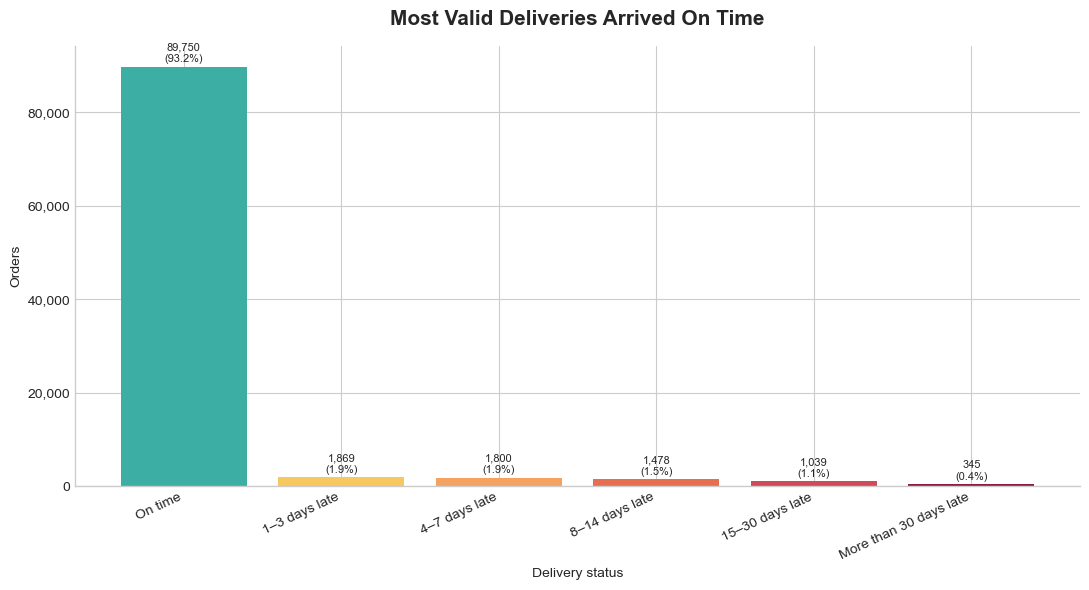

In [10]:
severity_colors = [
    COLORS["positive"],
    "#F6C85F",
    "#F4A261",
    "#E76F51",
    "#D1495B",
    "#8B1E3F"
]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    delay_severity_summary["delay_severity"].astype(str),
    delay_severity_summary["orders"],
    color=severity_colors
)

ax.set_title(
    "Most Valid Deliveries Arrived On Time",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Delivery status")
ax.set_ylabel("Orders")

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

plt.xticks(
    rotation=25,
    ha="right"
)

for bar, count, share in zip(
    bars,
    delay_severity_summary["orders"],
    delay_severity_summary["order_share"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1_000,
        f"{count:,.0f}\n({share:.1%})",
        ha="center",
        fontsize=8
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "delivery_delay_severity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** On-time deliveries received an average review score of 4.29, with 9.26% receiving low scores. For orders arriving only 1–3 days late, the average score fell to 3.29 and the low-satisfaction rate increased to 32.14%.

***Delay severity:*** Orders delayed by 4–7 days had a 67.64% low-satisfaction rate. The rate exceeded 80% for delays of 8–30 days, showing that more serious delays are associated with extremely poor review outcomes.

***Extreme delays:*** Orders delayed by more than 30 days had a slightly higher average score than the 8–30-day groups, but the group contains only 329 reviewed orders and still recorded a 67.78% low-satisfaction rate. The non-linear result should not be interpreted as extreme delays improving satisfaction.

***Commercial context:*** Approximately R$1.15 million in recorded payment value was associated with late deliveries. This represents transaction value exposed to poor delivery experiences, not proven lost revenue or guaranteed recoverable value.

***Analytical boundary:*** The results establish a strong historical association between delay severity and review outcomes. They do not prove that delivery delay was the sole cause of each low review.

## 3. Monthly Delivery Performance

Monthly delivery metrics are calculated using the purchase month. The comparison focuses on January 2017 through August 2018 to avoid incomplete boundary periods.

In [14]:
valid_deliveries["purchase_month_start"] = (
    valid_deliveries["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_delivery_performance = (
    valid_deliveries
    .groupby("purchase_month_start", as_index=False)
    .agg(
        valid_deliveries=("order_id", "nunique"),
        late_deliveries=("is_late_delivery", "sum"),
        average_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        average_review_score=("latest_review_score", "mean")
    )
)

monthly_delivery_performance["late_delivery_rate"] = (
    monthly_delivery_performance["late_deliveries"]
    / monthly_delivery_performance["valid_deliveries"]
)

monthly_delivery_performance["rolling_3_month_late_rate"] = (
    monthly_delivery_performance["late_delivery_rate"]
    .rolling(window=3, min_periods=1)
    .mean()
)

monthly_delivery_comparison = (
    monthly_delivery_performance.loc[
        monthly_delivery_performance[
            "purchase_month_start"
        ].between(
            "2017-01-01",
            "2018-08-01"
        )
    ]
    .copy()
    .reset_index(drop=True)
)

monthly_delivery_comparison[
    "rolling_3_month_late_rate"
] = (
    monthly_delivery_comparison[
        "late_delivery_rate"
    ]
    .rolling(window=3, min_periods=1)
    .mean()
)

monthly_delivery_comparison.style.format({
    "valid_deliveries": "{:,.0f}",
    "late_deliveries": "{:,.0f}",
    "average_delivery_days": "{:.2f}",
    "median_delivery_days": "{:.2f}",
    "average_review_score": "{:.2f}",
    "late_delivery_rate": "{:.2%}",
    "rolling_3_month_late_rate": "{:.2%}"
})

,purchase_month_start,valid_deliveries,late_deliveries,average_delivery_days,median_delivery_days,average_review_score,late_delivery_rate,rolling_3_month_late_rate
0,2017-01-01 00:00:00,749,22,12.64,10.72,4.20,2.94%,2.94%
1,2017-02-01 00:00:00,"1,651",49,13.18,10.97,4.20,2.97%,2.95%
2,2017-03-01 00:00:00,"2,545",116,12.95,10.13,4.19,4.56%,3.49%
3,2017-04-01 00:00:00,"2,303",151,14.92,12.75,4.14,6.56%,4.69%
4,2017-05-01 00:00:00,"3,544",106,11.32,9.79,4.24,2.99%,4.70%
5,2017-06-01 00:00:00,"3,134",95,12.01,10.80,4.22,3.03%,4.19%
6,2017-07-01 00:00:00,"3,861",108,11.61,10.17,4.26,2.80%,2.94%
7,2017-08-01 00:00:00,"4,191",122,11.15,9.80,4.31,2.91%,2.91%
8,2017-09-01 00:00:00,"4,149",181,11.84,10.31,4.27,4.36%,3.36%
9,2017-10-01 00:00:00,"4,478",187,11.86,10.26,4.20,4.18%,3.82%


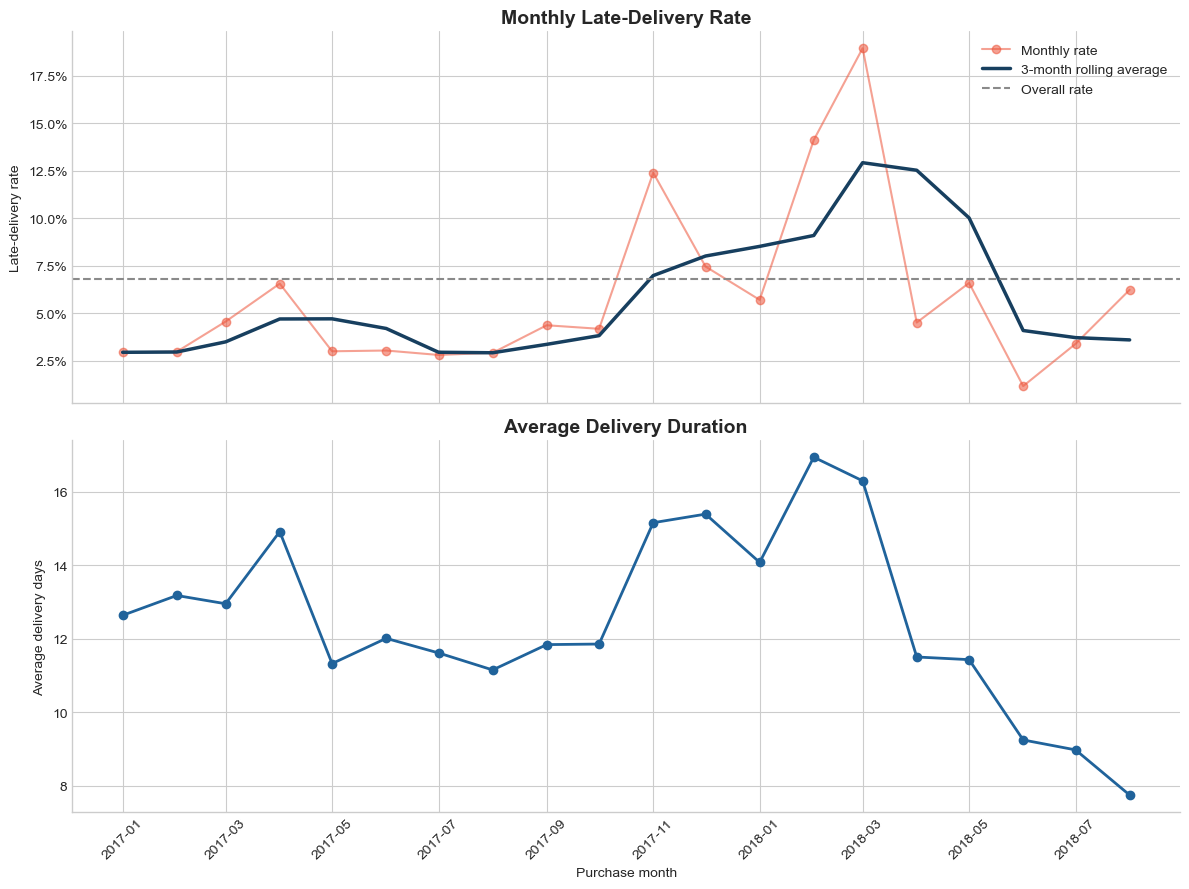

In [15]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    sharex=True
)

axes[0].plot(
    monthly_delivery_comparison[
        "purchase_month_start"
    ],
    monthly_delivery_comparison[
        "late_delivery_rate"
    ],
    color=COLORS["negative"],
    marker="o",
    linewidth=1.5,
    alpha=0.55,
    label="Monthly rate"
)

axes[0].plot(
    monthly_delivery_comparison[
        "purchase_month_start"
    ],
    monthly_delivery_comparison[
        "rolling_3_month_late_rate"
    ],
    color=COLORS["primary"],
    linewidth=2.5,
    label="3-month rolling average"
)

axes[0].axhline(
    len(late_deliveries) / len(valid_deliveries),
    color=COLORS["neutral"],
    linestyle="--",
    label="Overall rate"
)

axes[0].set_title(
    "Monthly Late-Delivery Rate",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_ylabel("Late-delivery rate")
axes[0].yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)
axes[0].legend()

axes[1].plot(
    monthly_delivery_comparison[
        "purchase_month_start"
    ],
    monthly_delivery_comparison[
        "average_delivery_days"
    ],
    color=COLORS["secondary"],
    marker="o",
    linewidth=2
)

axes[1].set_title(
    "Average Delivery Duration",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_ylabel("Average delivery days")
axes[1].set_xlabel("Purchase month")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "monthly_delivery_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
worst_month = monthly_delivery_comparison.loc[
    monthly_delivery_comparison[
        "late_delivery_rate"
    ].idxmax()
]

best_month = monthly_delivery_comparison.loc[
    monthly_delivery_comparison[
        "late_delivery_rate"
    ].idxmin()
]

print(
    "Highest late-delivery month:",
    worst_month["purchase_month_start"].strftime("%Y-%m"),
    f"({worst_month['late_delivery_rate']:.2%})"
)

print(
    "Lowest late-delivery month:",
    best_month["purchase_month_start"].strftime("%Y-%m"),
    f"({best_month['late_delivery_rate']:.2%})"
)

Highest late-delivery month: 2018-03 (18.96%)
Lowest late-delivery month: 2018-06 (1.16%)


***Observation:*** Monthly delivery performance varied substantially. The late-delivery rate reached its highest level in March 2018 at 18.96%, while June 2018 recorded the lowest rate at 1.16%.

***Operational pattern:*** Elevated late-delivery rates occurred in November 2017, February 2018, and March 2018. March also recorded an average review score of 3.81, compared with scores above 4.30 during the low-delay months of June through August 2018.

***Capacity hypothesis:*** November 2017 combined the project’s highest delivered order volume with a 12.40% late-delivery rate, which may indicate seasonal capacity pressure. However, order volume alone cannot explain the February and March 2018 deterioration and should be tested alongside seller, region, and category factors.

***Improvement pattern:*** Delivery duration fell considerably after March 2018, reaching an average of 7.74 days in August. This historical improvement should not be described as permanent because the dataset ends shortly afterward.

## 4. Product-Category Delivery Performance

Delivery performance is compared across product categories using one record per order-category combination. Rankings require at least 500 valid delivery orders to reduce instability from small category samples.

In [17]:
order_items = pd.read_csv(
    PROCESSED_DATA_DIR / "order_items_clean.csv"
)

products = pd.read_csv(
    PROCESSED_DATA_DIR / "products_clean.csv"
)

category_translation = pd.read_csv(
    PROCESSED_DATA_DIR
    / "category_translation_clean.csv"
)

In [18]:
category_order_bridge = (
    order_items
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left",
        validate="many_to_one"
    )
    .groupby(
        [
            "order_id",
            "product_category_name_english"
        ],
        as_index=False
    )
    .agg(
        category_item_count=("order_item_id", "count"),
        category_product_value=("price", "sum"),
        category_freight_value=("freight_value", "sum")
    )
)

In [19]:
category_order_bridge = category_order_bridge.merge(
    order_analytics[
        [
            "order_id",
            "is_valid_for_delivery_analysis",
            "is_late_delivery",
            "delivery_days",
            "delivery_delay_days",
            "latest_review_score"
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one"
)

category_order_bridge[
    "low_satisfaction_flag"
] = np.where(
    category_order_bridge[
        "latest_review_score"
    ].notna(),
    (
        category_order_bridge[
            "latest_review_score"
        ] <= 2
    ).astype(int),
    np.nan
)

In [20]:
category_bridge_validation = pd.DataFrame([
    {
        "validation_check": "Duplicate order-category combinations",
        "result": category_order_bridge.duplicated(
            subset=[
                "order_id",
                "product_category_name_english"
            ]
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Item records represented",
        "result": category_order_bridge[
            "category_item_count"
        ].sum(),
        "expected": len(order_items)
    },
    {
        "validation_check": "Product value represented",
        "result": round(
            category_order_bridge[
                "category_product_value"
            ].sum(),
            2
        ),
        "expected": round(
            order_items["price"].sum(),
            2
        )
    }
])

category_bridge_validation["status"] = np.where(
    np.isclose(
        category_bridge_validation["result"],
        category_bridge_validation["expected"],
        atol=0.01
    ),
    "Passed",
    "Failed"
)

category_bridge_validation

,validation_check,result,expected,status
0,Duplicate order-category combinations,0.00,0.00,Passed
1,Item records represented,"112,650.00","112,650.00",Passed
2,Product value represented,"13,591,643.70","13,591,643.70",Passed


In [21]:
valid_category_deliveries = (
    category_order_bridge.loc[
        category_order_bridge[
            "is_valid_for_delivery_analysis"
        ]
    ]
    .copy()
)

category_delivery_performance = (
    valid_category_deliveries
    .groupby(
        "product_category_name_english",
        as_index=False
    )
    .agg(
        valid_delivery_orders=("order_id", "nunique"),
        late_delivery_rate=("is_late_delivery", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        average_review_score=("latest_review_score", "mean"),
        low_satisfaction_rate=(
            "low_satisfaction_flag",
            "mean"
        ),
        product_value=("category_product_value", "sum")
    )
)

reliable_category_comparison = (
    category_delivery_performance.loc[
        category_delivery_performance[
            "valid_delivery_orders"
        ] >= 500
    ]
    .sort_values(
        "late_delivery_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Categories meeting the minimum:",
    len(reliable_category_comparison)
)

reliable_category_comparison.head(10).style.format({
    "valid_delivery_orders": "{:,.0f}",
    "late_delivery_rate": "{:.2%}",
    "average_delivery_days": "{:.2f}",
    "average_review_score": "{:.2f}",
    "low_satisfaction_rate": "{:.2%}",
    "product_value": "R$ {:,.2f}"
})

Categories meeting the minimum: 26


,product_category_name_english,valid_delivery_orders,late_delivery_rate,average_delivery_days,average_review_score,low_satisfaction_rate,product_value
0,office_furniture,"1,253",8.06%,20.65,3.64,21.96%,"R$ 267,984.37"
1,baby,"2,805",8.06%,12.69,4.10,14.30%,"R$ 400,203.40"
2,electronics,"2,512",7.64%,12.93,4.13,13.16%,"R$ 154,682.06"
3,musical_instruments,610,7.54%,13.09,4.23,11.75%,"R$ 183,686.74"
4,health_beauty,"8,629",7.52%,12.08,4.23,11.43%,"R$ 1,231,510.16"
5,bed_bath_table,"9,250",7.45%,13.00,4.00,16.05%,"R$ 1,021,560.81"
6,watches_gifts,"5,482",7.41%,12.82,4.12,13.71%,"R$ 1,163,762.82"
7,construction_tools_construction,736,7.34%,10.86,4.13,13.27%,"R$ 142,108.49"
8,auto,"3,792",7.30%,12.35,4.14,13.04%,"R$ 577,489.96"
9,unknown,"1,390",7.27%,12.74,4.01,17.46%,"R$ 170,571.73"


***Observation:*** Office furniture and baby products recorded the highest late-delivery rates among sufficiently represented categories, both at 8.06%. However, office furniture performed substantially worse in customer experience, with a 3.64 average review score, 21.96% low satisfaction, and an average delivery time of 20.65 days.

***Commercial exposure:*** Health and beauty, bed, bath and table, and watches and gifts combine above-average late-delivery rates with large delivered product values. These categories may create greater aggregate operational exposure even when their individual review outcomes are stronger than office furniture.

***Category-mix insight:*** Baby products have the same late-delivery rate as office furniture but considerably higher average satisfaction. This indicates that lateness alone does not fully explain category review outcomes; delay severity, product expectations, seller performance, and product quality may also matter.

***Analytical limitation:*** Multi-category orders appear once within each relevant category, so category order counts and product values should not be added together across categories.

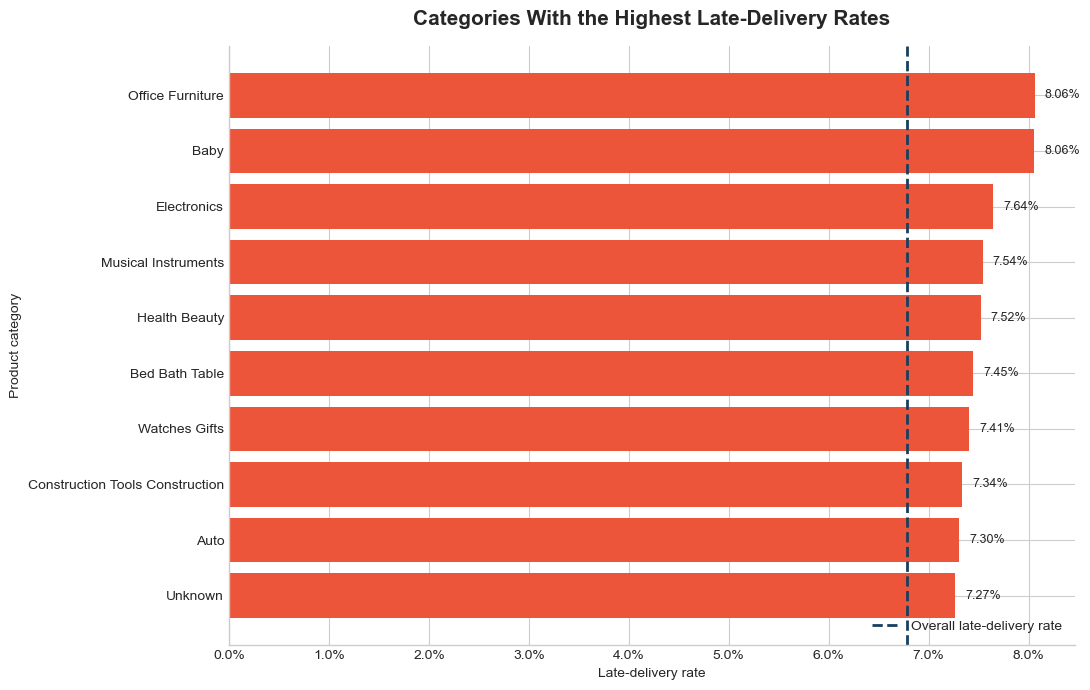

In [22]:
category_chart_data = (
    reliable_category_comparison
    .head(10)
    .sort_values(
        "late_delivery_rate",
        ascending=True
    )
    .copy()
)

category_chart_data["category_label"] = (
    category_chart_data[
        "product_category_name_english"
    ]
    .str.replace("_", " ")
    .str.title()
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    category_chart_data["category_label"],
    category_chart_data["late_delivery_rate"],
    color=COLORS["negative"]
)

ax.axvline(
    len(late_deliveries) / len(valid_deliveries),
    color=COLORS["primary"],
    linestyle="--",
    linewidth=2,
    label="Overall late-delivery rate"
)

ax.set_title(
    "Categories With the Highest Late-Delivery Rates",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Late-delivery rate")
ax.set_ylabel("Product category")

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

for bar, rate in zip(
    bars,
    category_chart_data["late_delivery_rate"]
):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2%}",
        va="center",
        fontsize=9
    )

ax.legend(loc="lower right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "category_late_delivery_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Chart interpretation:*** All ten displayed categories exceeded the overall late-delivery rate of 6.78%. Operational prioritisation should combine these rates with category volume, product value, satisfaction, and seller-level evidence.

## 5. Export Delivery Outputs

Delivery summaries are exported for use in Power BI, seller analysis, customer-satisfaction analysis, and the executive presentation.

In [23]:
delivery_outputs = {
    "delivery_delay_severity.csv":
        delay_severity_summary,
    "monthly_delivery_performance.csv":
        monthly_delivery_comparison,
    "category_delivery_performance.csv":
        category_delivery_performance
}

delivery_export_records = []

for filename, dataframe in delivery_outputs.items():
    output_path = (
        PROCESSED_DATA_DIR / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
        date_format="%Y-%m-%d"
    )

    delivery_export_records.append({
        "output_file": filename,
        "rows": len(dataframe),
        "columns": dataframe.shape[1],
        "file_created": output_path.exists()
    })

delivery_export_summary = pd.DataFrame(
    delivery_export_records
)

delivery_export_summary

,output_file,rows,columns,file_created
0,delivery_delay_severity.csv,6,9,True
1,monthly_delivery_performance.csv,20,8,True
2,category_delivery_performance.csv,74,7,True


In [24]:
expected_delivery_charts = [
    "delivery_delay_severity_distribution.png",
    "monthly_delivery_performance.png",
    "category_late_delivery_rates.png"
]

delivery_chart_validation = pd.DataFrame({
    "chart_file": expected_delivery_charts,
    "file_created": [
        (IMAGE_OUTPUT_DIR / filename).exists()
        for filename in expected_delivery_charts
    ]
})

delivery_chart_validation

,chart_file,file_created
0,delivery_delay_severity_distribution.png,True
1,monthly_delivery_performance.png,True
2,category_late_delivery_rates.png,True


In [25]:
print(
    "Delivery tables exported:",
    delivery_export_summary[
        "file_created"
    ].sum()
)

print(
    "All delivery tables created:",
    delivery_export_summary[
        "file_created"
    ].all()
)

print(
    "Delivery charts exported:",
    delivery_chart_validation[
        "file_created"
    ].sum()
)

print(
    "All delivery charts created:",
    delivery_chart_validation[
        "file_created"
    ].all()
)

Delivery tables exported: 3
All delivery tables created: True
Delivery charts exported: 3
All delivery charts created: True


## Conclusion

***Overall performance:*** Among 96,281 valid deliveries, 93.22% arrived on or before the estimated date and 6.78% arrived late. Median delivery time was 10.23 days, while late orders missed their deadline by an average of 10.62 days.

***Customer-experience impact:*** Review outcomes deteriorated sharply as delays became more severe. Low satisfaction increased from 9.26% for on-time deliveries to 32.14% for delays of 1–3 days and exceeded 67% for delays of 4–30 days.

***Time pattern:*** The late-delivery rate peaked at 18.96% in March 2018 and fell to 1.16% in June 2018. Delivery performance improved during the final complete months, although the dataset does not establish whether that improvement continued.

***Category priority:*** Office furniture combined a high late-delivery rate with the longest average delivery time and weakest review results among the leading category-risk groups. High-value categories such as health and beauty, bed, bath and table, and watches and gifts also require monitoring because of their larger commercial exposure.

***Analytical boundaries:*** Delivery and satisfaction results describe historical associations and do not prove causation. Recorded payment value associated with late orders is not equivalent to lost or recoverable revenue.

***Outputs:*** Three delivery-analysis tables and three charts were exported successfully.

***Next step:*** `07_customer_satisfaction_analytics.ipynb` will investigate review outcomes by delivery status, category, payment behaviour, order value, geography, and seller involvement.